<a href="https://colab.research.google.com/github/jaidena121/Orbyts-2026/blob/main/Datapoint174.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tutorial: DESI spectral fitting with `provabgs`

Copy of the tutorial from provabgs. First we install the relevant libraries

In [1]:
# lets install the python package `provabgs`, a python package for generating the PRObabilistic Value-Added BGS (PROVABGS)
!pip install git+https://github.com/changhoonhahn/provabgs.git --upgrade --user
!pip install fitsio
!pip install desispec

  Cloning https://github.com/changhoonhahn/provabgs.git to /tmp/pip-req-build-jrgw38q8
  Running command git clone --filter=blob:none --quiet https://github.com/changhoonhahn/provabgs.git /tmp/pip-req-build-jrgw38q8
  Resolved https://github.com/changhoonhahn/provabgs.git to commit f192008df8a03cfbdbb35d1b0128def4c1424752
  Preparing metadata (setup.py) ... done


In [2]:
import os
os.environ['PATH'] += '/root/.local/bin'

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!pip install zeus-mcmc --user
!export SPS_HOME="/content/python-fsps"
!git clone --recursive https://github.com/dfm/python-fsps.git $SPS_HOME
!python -m pip install /content/python-fsps

fatal: destination path 'python-fsps' already exists and is not an empty directory.
Processing ./python-fsps
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for fsps: filename=fsps-0.4.8.dev82+g5a76de1c5-cp312-cp312-linux_x86_64.whl size=249311 sha256=503c2e1e4d8c1d8cf2340f6c8f4bd0e4bb3fa6b28bffef10c681fdc3968c5141
  Stored in directory: /root/.cache/pip/wheels/08/3e/c8/9b9a61a59a94d1ed312d894993627eb8b13f9f55ff68f35e50
Successfully built fsps
  Attempting uninstall: fsps
    Found existing installation: fsps 0.4.8.dev82+g5a76de1c5
    Uninstalling fsps-0.4.8.dev82+g5a76de1c5:
      Successfully uninstalled fsps-0.4.8.dev82+g5a76de1c5


In [5]:
import numpy as np

Check that desispect, fitsio, fsps and provabgs are properly installed by listing all the libraries available

In [6]:
!pip list

Package                                  Version
---------------------------------------- ----------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                      

In [7]:
import os
os.environ["SPS_HOME"] = r'/content/python-fsps/src/fsps/libfsps'

In [8]:
from provabgs import infer as Infer
from provabgs import models as Models
from provabgs import flux_calib as FluxCalib

In [9]:
# -- plotting --
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False

The data isn't at the same location as in the PROVABGS tutorial, so make sure that 'coadd-0-80612-thru20201223.fits' is somewhere in your locally accessible files and point to that location.

In [10]:
# read in DESI Cascades spectra from TILE 80612
from desispec.io import read_spectra

spectra = read_spectra('/content/coadd-0-174-thru20210405.fits')

INFO:spectra.py:453:read_spectra: iotime 1.135 sec to read spectra from:  coadd-0-174-thru20210405.fits at 2026-03-01T18:55:18.669742


INFO:desiutil.log.dlm58.info:iotime 1.135 sec to read spectra from:  coadd-0-174-thru20210405.fits at 2026-03-01T18:55:18.669742


In [11]:
igal = 10

Now make sure you have 'zmtl-0-80612-thru20201223.fits' locally as well and point to the right location

In [12]:
from astropy.table import Table
zbest = Table.read('/content/zmtl-0-174-thru20210405.fits', hdu=1)
zred = zbest['Z'][igal]
print('z=%f' % zred)

z=0.000081


(0.0, 5.0)

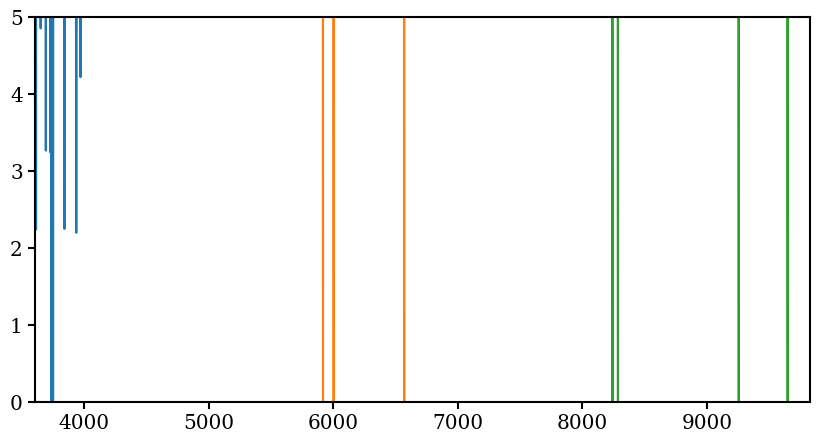

In [13]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.plot(spectra.wave['b'], spectra.flux['b'][igal])
sub.plot(spectra.wave['r'], spectra.flux['r'][igal])
sub.plot(spectra.wave['z'], spectra.flux['z'][igal])
sub.set_xlim(spectra.wave['b'].min(), spectra.wave['z'].max())
sub.set_ylim(0, 5)

In [14]:
# declare prior
priors = Infer.load_priors([
    Infer.UniformPrior(9., 12, label='sed'),
    Infer.FlatDirichletPrior(4, label='sed'),
    Infer.UniformPrior(np.array([6.9e-5, 6.9e-5, 0., 0., -2.2]), np.array([7.3e-3, 7.3e-3, 3., 4., 0.4]), label='sed'),
    Infer.UniformPrior(np.array([0.9, 0.9, 0.9]), np.array([1.1, 1.1, 1.1]), label='flux_calib') # flux calibration variables
    ])

# declare model
m_nmf = Models.NMF(burst=False, emulator=False)

# declare flux calibration
fluxcalib = FluxCalib.constant_flux_DESI_arms

input parameters : logmstar, beta1_sfh, beta2_sfh, beta3_sfh, beta4_sfh, gamma1_zh, gamma2_zh, dust1, dust2, dust_index


In [15]:
desi_mcmc = Infer.desiMCMC(
    model=m_nmf,
    flux_calib=fluxcalib,
    prior=priors
)

In [ ]:
mcmc = desi_mcmc.run(
    wave_obs=[spectra.wave['b'], spectra.wave['r'], spectra.wave['z']],
    flux_obs=[spectra.flux['b'][igal], spectra.flux['r'][igal], spectra.flux['z'][igal]],
    flux_ivar_obs=[spectra.ivar['b'][igal], spectra.ivar['r'][igal], spectra.ivar['z'][igal]],
    zred=zred,
    sampler='zeus',
    nwalkers=100,
    burnin=100,
    opt_maxiter=10000,
    niter=100,
    debug=True)

--- initializing the walkers ---


Initialising ensemble of 100 walkers...


initial theta = [9.0, 0.5437638935830729, 0.48407950458915827, 0.6261878742475389, 0.005066058320004948, 0.0030763923844806494, 0.8034897937976797, 2.48743122533776, -0.8123763854913983, 1.0961232209613814, 1.0999999999999917, 0.9000483412704161]
log Posterior(theta0) = -217381511432449.312500
--- running MCMC ---


Sampling progress :  56%|█████▋    | 113/200 [2:37:08<1:57:08, 80.78s/it]

In [ ]:
fig = plt.figure(figsize=(10,5))
sub = fig.add_subplot(111)
sub.plot(spectra.wave['b'], spectra.flux['b'][igal])
sub.plot(spectra.wave['r'], spectra.flux['r'][igal])
sub.plot(spectra.wave['z'], spectra.flux['z'][igal])
sub.plot(mcmc['wavelength_obs'], mcmc['flux_spec_model'], c='k', ls='--')
sub.set_xlim(spectra.wave['b'].min(), spectra.wave['z'].max())
sub.set_ylim(0, 5)